<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 3.1}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Ayudante de laboratorio:} & Diego Eduardo Peña Villegas \\[6pt]
\textbf{Alumna:} & Giovanni Alejandri Espinosa \\[6pt]
\textbf{Fecha de realización:} & 25/02/2026
\end{array}

</center>

# Fundamentos de Naive Bayes

**Objetivo**:
Implementar el algoritmo Naive Bayes para clasificar objetos basados en características continuas/discretas, comparando la lógica manual con la implementación de scikit-learn.

# Introducción Teórica
Naive Bayes se basa en la suposición de que las características (peso y textura) son independientes entre sí dada la clase. Aunque en la realidad esto rara vez se cumple, el algoritmo es extremadamente eficiente y sirve como "baseline" para modelos más complejos.

**Actividades de los alumnos**:

- **Cálculo manual**: Antes de programar, calculen en papel la probabilidad para una fruta de 180g y textura 6 usando los promedios de la tabla.

- **Análisis de la Gaussiana**: ¿Qué sucede si la desviación estándar de una característica es 0?  

- **Comparativa**: Modifique los datos para que una Toronja sea muy ligera. ¿Cómo reacciona el modelo? ¿Es más sensible al peso o a la textura?

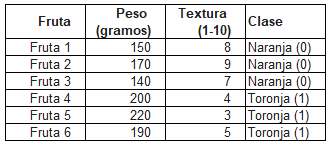

### Cálculo manual

Para la clase Naranja:

$$
\mu_{peso} = \frac{150 + 170 + 140}{3} = 153.33
$$

$$
\mu_{textura} = \frac{8 + 9 + 7}{3} = 8
$$

Para la clase Toronja:

$$
\mu_{peso} = \frac{200 + 220 + 190}{3} = 203.33
$$

$$
\mu_{textura} = \frac{4 + 3 + 5}{3} = 4
$$

Se utiliza la fórmula de Naive Bayes:

$$
P(N \mid P, T) \propto P(N)\cdot P(P \mid N)\cdot P(T \mid N)
$$

### Análisis de la Gaussiana

La distribución gaussiana está dada por:

$$
P(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x - \mu)^2}{2\sigma^2}\right)
$$

Si $\sigma = 0$, se produce una división entre cero, lo que genera errores en el cálculo.

Para evitar esto, se reemplaza por un valor pequeño:

$$
\sigma = \max(\sigma, 1 \times 10^{-6})
$$

### Comparativa

Si se modifica el dataset para que una toronja tenga un peso muy bajo, el modelo puede confundirse, ya que sus características se acercan a las de una naranja.

El modelo es más sensible a la característica con menor desviación estándar, ya que esta tiene mayor impacto en el cálculo de la probabilidad.

# 1. Implementación con Bibliotecas (sklearn)

Esta versión muestra cómo el mismo problema se resuelve con estándares industriales.

In [ ]:
import numpy as np

# Datos
X = np.array([
    [150, 8],
    [170, 9],
    [140, 7],
    [200, 4],
    [220, 3],
    [190, 5]
])

y = np.array([0, 0, 0, 1, 1, 1])  # 0=Naranja, 1=Toronja

In [ ]:
from sklearn.naive_bayes import GaussianNB

# Modelo
modelo = GaussianNB()

# Entrenar
modelo.fit(X, y)

# Predecir
nueva_fruta = [[180, 6]]
prediccion = modelo.predict(nueva_fruta)

print("Predicción:", "Naranja" if prediccion[0] == 0 else "Toronja")

Predicción: Toronja


# 1. Implementación "Desde Cero" (Numpy)

Usaremos un dataset pequeño donde clasificamos si una fruta es Naranja o Toronja basándonos en dos características: Peso (g) y Textura (1-10).El AlgoritmoLos alumnos deben calcular la probabilidad de que una fruta sea una Naranja ($N$) dado que pesa 150g ($P$) y tiene textura 8 ($T$):

$$P(N | P, T) \propto P(N) \cdot P(P | N) \cdot P(T | N)$$

In [ ]:
import numpy as np

# Datos
X = np.array([
    [150, 8],
    [170, 9],
    [140, 7],
    [200, 4],
    [220, 3],
    [190, 5]
])

y = np.array([0, 0, 0, 1, 1, 1])  # 0=Naranja, 1=Toronja

# Separar clases
X_naranja = X[y == 0]
X_toronja = X[y == 1]

# Función gaussiana
def gaussian(x, mean, std):
    std = max(std, 1e-6)  # evitar división por 0
    return (1 / (np.sqrt(2 * np.pi) * std)) * np.exp(-((x - mean) ** 2) / (2 * std ** 2))

# Calcular medias y desviaciones
def calcular_parametros(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    return mean, std

mean_n, std_n = calcular_parametros(X_naranja)
mean_t, std_t = calcular_parametros(X_toronja)

# Probabilidades a priori
p_naranja = len(X_naranja) / len(X)
p_toronja = len(X_toronja) / len(X)

# Nueva fruta
nueva_fruta = np.array([180, 6])

# Probabilidades
p_x_naranja = gaussian(nueva_fruta[0], mean_n[0], std_n[0]) * \
              gaussian(nueva_fruta[1], mean_n[1], std_n[1])

p_x_toronja = gaussian(nueva_fruta[0], mean_t[0], std_t[0]) * \
              gaussian(nueva_fruta[1], mean_t[1], std_t[1])

posterior_naranja = p_naranja * p_x_naranja
posterior_toronja = p_toronja * p_x_toronja

print("Probabilidad Naranja:", posterior_naranja)
print("Probabilidad Toronja:", posterior_toronja)

if posterior_naranja > posterior_toronja:
    print("Clasificación: NARANJA")
else:
    print("Clasificación: TORONJA")

Probabilidad Naranja: 3.956730358646456e-05
Probabilidad Toronja: 6.760739671442136e-05
Clasificación: TORONJA


<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>